# 03 — Modélisation — Axe 2 : Stroke Severity (Version 2 — Améliorée)

**Projet :** Stroke Prediction AI — IST Dataset  
**Notebook :** 03 — Modélisation V2  
**Version :** V2 — Pipeline corrigé + visualisations complètes  
**Dataset :** `IST_corrected.csv` — 19 435 patients · 112 variables  
**Auteur :** ML_Project 2025-2026

---

## Objectif de ce notebook

Ce notebook est la version **améliorée** de la modélisation V1.  
Il intègre les corrections du preprocessing V2 et ajoute une **analyse visuelle complète**  
des performances des modèles selon les métriques prioritaires du projet.

## Métriques prioritaires — Axe 2

| Métrique | Priorité | Justification |
|----------|----------|---------------|
| **F1-macro** | Principale | Équilibre toutes les classes — recommandée dans le cahier des charges |
| **Recall sévère** | Critique | Un faux négatif (cas grave raté) est plus dangereux qu'un faux positif |
| **Accuracy** | Secondaire | Trompeuse avec déséquilibre — montrée pour comparaison uniquement |
| **Precision par classe** | Complémentaire | Détecte les faux positifs par classe |

## Plan de ce notebook

| Section | Contenu |
|---------|---------|
| **1** | Configuration + imports |
| **2** | Chargement artefacts V2 |
| **3** | Définition des 5 modèles (+ XGBoost) |
| **4** | Validation croisée stratifiée — F1-macro + Recall sévère |
| **5** | Entraînement et évaluation sur test |
| **6** | Graphiques comparatifs des performances |
| **7** | Analyse par classe : F1, Recall, Precision |
| **8** | Matrices de confusion comparatives |
| **9** | Meilleur modèle : rapport détaillé + courbe ROC multiclasse |
| **10** | GridSearchCV sur le meilleur modèle |
| **11** | Feature importance |
| **12** | Comparaison finale V1 vs V2 |
| **13** | Sauvegarde + conclusion |

---


---
## Section 1 — Configuration et imports


In [1]:
# ============================================================
# 1.1 — Imports standards ML + XGBoost
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os, sys, json, joblib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# sklearn — modèles et évaluation
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics         import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing   import label_binarize

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost disponible")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost non disponible — pip install xgboost")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

# Constantes
LABEL_ORDER = ["leger", "modere", "severe"]
LABEL_MAP   = {"leger": 0, "modere": 1, "severe": 2}
LABEL_MAP_INV = {0: "léger", 1: "modéré", 2: "sévère"}
COLORS_CLASS = {"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"}
COLORS_MODEL = {
    "LogisticRegression": "#3498db",
    "DecisionTree"      : "#9b59b6",
    "RandomForest"      : "#2ecc71",
    "GradientBoosting"  : "#e67e22",
    "XGBoost"           : "#e74c3c",
}

print("Tous les imports chargés")


XGBoost disponible
Tous les imports chargés


In [2]:
# ============================================================
# 1.2 — Montage Drive + configuration
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT  = Path("/content/drive/MyDrive/ML_Project")
SRC_PATH      = PROJECT_ROOT / "src"
ARTIFACTS_V2  = PROJECT_ROOT / "artifacts" / "axe2" / "v2"
MODELS_V2_DIR = ARTIFACTS_V2 / "models"
MODELS_V2_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import importlib, config
importlib.reload(config)
from config import DATA_PATH, RANDOM_STATE

print(f"ARTIFACTS_V2  : {ARTIFACTS_V2}")
print(f"MODELS_V2_DIR : {MODELS_V2_DIR}")
print(f"RANDOM_STATE  : {RANDOM_STATE}")
print("Configuration chargée")


Mounted at /content/drive
ARTIFACTS_V2  : /content/drive/MyDrive/ML_Project/artifacts/axe2/v2
MODELS_V2_DIR : /content/drive/MyDrive/ML_Project/artifacts/axe2/v2/models
RANDOM_STATE  : 42
Configuration chargée


---
## Section 2 — Chargement des artefacts V2

### 2.1 Données produites par le notebook 02 V2

Le notebook 02 V2 a produit :
- `X_train_smote.csv` : train après SMOTE (classe sévère équilibrée)
- `X_test_preprocessed.csv` : test preprocessing (sans SMOTE — jamais)
- `y_train_smote.csv` / `y_test.csv` : labels encodés (0/1/2)


In [3]:
# ============================================================
# 2.1 — Chargement des artefacts V2
# ============================================================

X_train = pd.read_csv(ARTIFACTS_V2 / "X_train_smote.csv")
X_test  = pd.read_csv(ARTIFACTS_V2 / "X_test_preprocessed.csv")
y_train = pd.read_csv(ARTIFACTS_V2 / "y_train_smote.csv").squeeze()
y_test  = pd.read_csv(ARTIFACTS_V2 / "y_test.csv", index_col=0).squeeze()

print("Artefacts V2 chargés :")
print(f"  X_train (après SMOTE) : {X_train.shape}")
print(f"  X_test                : {X_test.shape}")
print(f"  y_train (après SMOTE) : {y_train.shape}")
print(f"  y_test                : {y_test.shape}")

print()
print("Distribution y_train (après SMOTE) :")
ct = Counter(y_train)
for k in sorted(ct): print(f"  {LABEL_MAP_INV[k]:8s} ({k}) : {ct[k]:5d} ({ct[k]/len(y_train)*100:.1f}%)")

print()
print("Distribution y_test (sans SMOTE — évaluation honnête) :")
ct_test = Counter(y_test)
for k in sorted(ct_test): print(f"  {LABEL_MAP_INV[k]:8s} ({k}) : {ct_test[k]:5d} ({ct_test[k]/len(y_test)*100:.1f}%)")


Artefacts V2 chargés :
  X_train (après SMOTE) : (21983, 41)
  X_test                : (3884, 41)
  y_train (après SMOTE) : (21983,)
  y_test                : (3884,)

Distribution y_train (après SMOTE) :
  léger    (0) :  7753 (35.3%)
  modéré   (1) :  6477 (29.5%)
  sévère   (2) :  7753 (35.3%)

Distribution y_test (sans SMOTE — évaluation honnête) :
  léger    (0) :  1939 (49.9%)
  modéré   (1) :  1619 (41.7%)
  sévère   (2) :   326 (8.4%)


---
## Section 3 — Définition des modèles candidats (5 modèles — 3 familles)

### 3.1 Ajout de XGBoost en V2

Le cahier des charges recommande XGBoost pour cet axe.  
En V2, on passe de 4 à 5 modèles en ajoutant XGBoost.

**Remarque :** En V2, `class_weight='balanced'` est conservé en backup  
mais SMOTE est le mécanisme principal de gestion du déséquilibre.  
Les deux sont complémentaires et non exclusifs.


In [4]:
# ============================================================
# 3.1 — Définition des 5 modèles candidats
# ============================================================

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        random_state=RANDOM_STATE, solver="lbfgs", multi_class="multinomial"
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=4, random_state=RANDOM_STATE
    ),
}

# Ajout XGBoost si disponible
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        use_label_encoder=False, eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )

print(f"Modèles définis : {len(models)}")
for name in models:
    family = ("Linéaire" if "Logistic" in name
              else "Arbre" if "Tree" in name
              else "Boosting" if "Boosting" in name or "XGB" in name
              else "Bagging")
    print(f"  ✓ {name:25s} ({family})")


Modèles définis : 5
  ✓ LogisticRegression        (Linéaire)
  ✓ DecisionTree              (Arbre)
  ✓ RandomForest              (Bagging)
  ✓ GradientBoosting          (Boosting)
  ✓ XGBoost                   (Boosting)


---
## Section 4 — Validation croisée stratifiée

### 4.1 Deux métriques en CV

En V2, on calcule simultanément en CV :
- **F1-macro** : métrique principale (équilibre toutes les classes)
- **Recall macro** : priorité clinique (minimiser les faux négatifs sévères)

Cela donne une vision plus complète avant l'évaluation sur le test set.


In [5]:
# ============================================================
# 4.1 — Validation croisée 5-fold : F1-macro ET Recall
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

print("Validation croisée 5-fold (données SMOTE) :")
print("=" * 60)

for model_name, model in models.items():
    # F1-macro
    f1_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    # Recall macro (priorité clinique)
    rec_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="recall_macro", n_jobs=-1
    )
    # Accuracy
    acc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="accuracy", n_jobs=-1
    )

    cv_results.append({
        "model"           : model_name,
        "f1_macro_mean"   : f1_scores.mean(),
        "f1_macro_std"    : f1_scores.std(),
        "recall_mean"     : rec_scores.mean(),
        "recall_std"      : rec_scores.std(),
        "accuracy_mean"   : acc_scores.mean(),
        "accuracy_std"    : acc_scores.std(),
    })

    print(f"  {model_name:25s} | F1={f1_scores.mean():.4f}±{f1_scores.std():.4f} "
          f"| Recall={rec_scores.mean():.4f}±{rec_scores.std():.4f} "
          f"| Acc={acc_scores.mean():.4f}±{acc_scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("f1_macro_mean", ascending=False)
print()
print("Classement par F1-macro (CV) :")
display(cv_df.round(4))


Validation croisée 5-fold (données SMOTE) :
  LogisticRegression        | F1=0.8698±0.0029 | Recall=0.8693±0.0028 | Acc=0.8750±0.0028
  DecisionTree              | F1=0.8999±0.0051 | Recall=0.8984±0.0051 | Acc=0.9058±0.0047
  RandomForest              | F1=0.9261±0.0023 | Recall=0.9248±0.0022 | Acc=0.9301±0.0022
  GradientBoosting          | F1=0.9177±0.0040 | Recall=0.9163±0.0040 | Acc=0.9223±0.0038
  XGBoost                   | F1=0.9194±0.0056 | Recall=0.9182±0.0055 | Acc=0.9237±0.0053

Classement par F1-macro (CV) :


,model,f1_macro_mean,f1_macro_std,recall_mean,recall_std,accuracy_mean,accuracy_std
2,RandomForest,0.9261,0.0023,0.9248,0.0022,0.9301,0.0022
4,XGBoost,0.9194,0.0056,0.9182,0.0055,0.9237,0.0053
3,GradientBoosting,0.9177,0.0040,0.9163,0.0040,0.9223,0.0038
1,DecisionTree,0.8999,0.0051,0.8984,0.0051,0.9058,0.0047
0,LogisticRegression,0.8698,0.0029,0.8693,0.0028,0.8750,0.0028


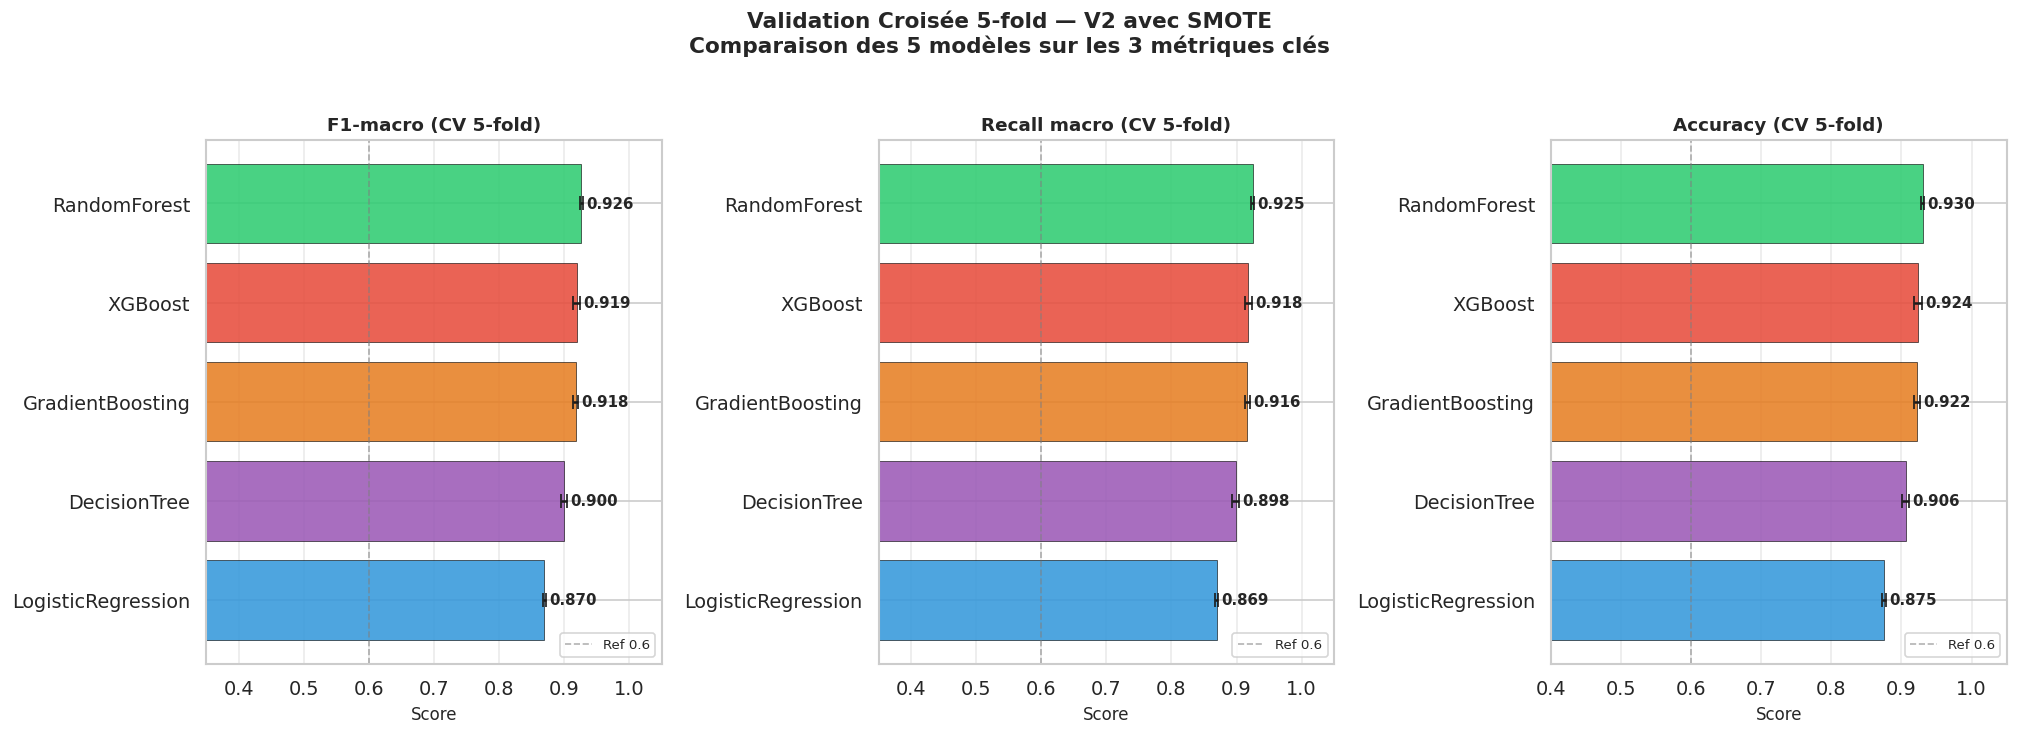

Graphique CV comparatif sauvegardé


In [6]:
# ============================================================
# 4.2 — Visualisation : résultats CV (F1-macro + Recall + Accuracy)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
metrics = [
    ("f1_macro_mean",  "f1_macro_std",  "F1-macro (CV 5-fold)",   0.35, "blue"),
    ("recall_mean",    "recall_std",    "Recall macro (CV 5-fold)", 0.35, "orange"),
    ("accuracy_mean",  "accuracy_std",  "Accuracy (CV 5-fold)",    0.40, "green"),
]

for ax, (mean_col, std_col, title, ymin, color) in zip(axes, metrics):
    cv_sorted = cv_df.sort_values(mean_col, ascending=True)
    bar_colors = [COLORS_MODEL.get(m, "#95a5a6") for m in cv_sorted["model"]]

    bars = ax.barh(
        cv_sorted["model"], cv_sorted[mean_col],
        xerr=cv_sorted[std_col], color=bar_colors,
        edgecolor="black", lw=0.4, capsize=4, alpha=0.87
    )
    for bar, val, std in zip(bars, cv_sorted[mean_col], cv_sorted[std_col]):
        ax.text(bar.get_width() + std + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_xlim(ymin, 1.05)
    ax.axvline(x=0.6, color="gray", linestyle="--", lw=1, alpha=0.6, label="Ref 0.6")
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.4)

plt.suptitle("Validation Croisée 5-fold — V2 avec SMOTE\nComparaison des 5 modèles sur les 3 métriques clés",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_cv_comparison_3metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique CV comparatif sauvegardé")


---
## Section 5 — Entraînement final et évaluation sur le test set

### 5.1 Métriques calculées sur le test set

En plus de la validation croisée, on calcule sur le test set :
- `accuracy`, `f1_macro`, `recall_macro`
- **Recall par classe** : `recall_leger`, `recall_modere`, `recall_severe`
- **F1 par classe** : `f1_leger`, `f1_modere`, `f1_severe`
- **Precision sévère** : complète le recall sévère

Le recall sur `sévère` est la métrique clinique la plus critique.


In [ ]:
# ============================================================
# 5.1 — Entraînement + évaluation sur test (toutes métriques)
# ============================================================

test_results    = []
trained_models  = {}
y_pred_all      = {}
y_proba_all     = {}

print("Entraînement sur X_train (SMOTE) + évaluation sur X_test :")
print("=" * 75)

for model_name, model in models.items():
    # Entraînement sur données SMOTE
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    # Prédictions
    y_pred = model.predict(X_test)
    y_pred_all[model_name] = y_pred

    # Probabilités (pour ROC)
    if hasattr(model, "predict_proba"):
        y_proba_all[model_name] = model.predict_proba(X_test)

    # Métriques globales
    acc      = accuracy_score(y_test, y_pred)
    f1_mac   = f1_score(y_test, y_pred, average="macro")
    rec_mac  = recall_score(y_test, y_pred, average="macro")

    # Métriques par classe
    report = classification_report(
        y_test, y_pred,
        labels=[0, 1, 2],
        target_names=LABEL_ORDER,
        output_dict=True
    )

    row = {
        "model"          : model_name,
        "accuracy"       : round(acc, 4),
        "f1_macro"       : round(f1_mac, 4),
        "recall_macro"   : round(rec_mac, 4),
        "recall_severe"  : round(report["severe"]["recall"], 4),
        "recall_modere"  : round(report["modere"]["recall"], 4),
        "recall_leger"   : round(report["leger"]["recall"], 4),
        "f1_severe"      : round(report["severe"]["f1-score"], 4),
        "f1_modere"      : round(report["modere"]["f1-score"], 4),
        "f1_leger"       : round(report["leger"]["f1-score"], 4),
        "precision_severe": round(report["severe"]["precision"], 4),
    }
    test_results.append(row)

    print(f"  {model_name:25s} | Acc={acc:.4f} | F1={f1_mac:.4f} | "
          f"Rec={rec_mac:.4f} | Rec_severe={report['severe']['recall']:.4f}")

test_df = pd.DataFrame(test_results).sort_values("f1_macro", ascending=False)
print()
print("Résultats complets :")
display(test_df)


Entraînement sur X_train (SMOTE) + évaluation sur X_test :
  LogisticRegression        | Acc=0.8568 | F1=0.7926 | Rec=0.8533 | Rec_severe=0.8650
  DecisionTree              | Acc=0.8702 | F1=0.8025 | Rec=0.8548 | Rec_severe=0.8344
  RandomForest              | Acc=0.8859 | F1=0.8019 | Rec=0.8145 | Rec_severe=0.6411


---
## Section 6 — Graphiques comparatifs des performances

### 6.1 Vue d'ensemble des 3 métriques principales

Ce graphique permet de comparer tous les modèles sur les 3 métriques  
les plus importantes pour ce projet : F1-macro, Recall et Accuracy.


In [ ]:
# ============================================================
# 6.1 — Graphique comparatif global (3 métriques × 5 modèles)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_info = [
    ("f1_macro",     "F1-macro",           "#3498db", 0.35),
    ("recall_macro", "Recall macro",        "#e67e22", 0.35),
    ("accuracy",     "Accuracy",            "#2ecc71", 0.40),
]

for ax, (metric, label, bar_color, ymin) in zip(axes, metrics_info):
    sorted_df = test_df.sort_values(metric, ascending=True)
    colors    = [COLORS_MODEL.get(m, "#95a5a6") for m in sorted_df["model"]]

    bars = ax.barh(
        sorted_df["model"], sorted_df[metric],
        color=colors, edgecolor="black", lw=0.4, alpha=0.88
    )
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9.5, fontweight="bold")

    ax.set_title(label, fontweight="bold", fontsize=12)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_xlim(ymin, 1.08)
    ax.axvline(0.6, color="gray", linestyle="--", lw=1, alpha=0.5)
    ax.text(0.605, 0.02, "0.6", color="gray", fontsize=8,
            transform=ax.get_xaxis_transform())
    ax.grid(axis="x", alpha=0.4)

# Légende des couleurs des modèles
legend_patches = [mpatches.Patch(color=c, label=m, alpha=0.88)
                  for m, c in COLORS_MODEL.items() if m in test_df["model"].values]
fig.legend(handles=legend_patches, title="Modèle", bbox_to_anchor=(0.5, -0.04),
           loc="upper center", ncol=5, fontsize=9)

plt.suptitle("Comparaison des modèles — Test set V2 (avec SMOTE)\nF1-macro | Recall macro | Accuracy",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_test_comparison_global.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Graphique comparatif global sauvegardé")


In [ ]:
# ============================================================
# 6.2 — Graphique spider (radar) des métriques par modèle
# ============================================================

import matplotlib
categories = ["F1-macro", "Recall macro", "Accuracy",
              "Recall sévère", "F1 sévère"]
metric_keys = ["f1_macro", "recall_macro", "accuracy", "recall_severe", "f1_severe"]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for _, row in test_df.iterrows():
    values = [row[k] for k in metric_keys]
    values += values[:1]
    color = COLORS_MODEL.get(row["model"], "#95a5a6")
    ax.plot(angles, values, linewidth=2, linestyle="solid", color=color, label=row["model"])
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8, color="gray")
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title("Profil de performance — Radar chart\nV2 avec SMOTE — Test set",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Radar chart sauvegardé")


---
## Section 7 — Analyse détaillée par classe : F1, Recall, Precision

### 7.1 Pourquoi analyser classe par classe ?

La F1-macro est une moyenne des F1 par classe.  
Elle peut masquer des performances très inégales entre classes.  
Un modèle peut avoir un bon F1-macro mais rater presque tous les cas sévères.

**Dans ce projet, la classe `sévère` est la plus importante cliniquement.**  
Son recall doit être le plus élevé possible (minimiser les cas graves ratés).


In [ ]:
# ============================================================
# 7.1 — F1-score par classe pour tous les modèles
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
class_metrics = [
    ("f1_leger",   "f1_modere",   "f1_severe",        "F1-score par classe"),
    ("recall_leger","recall_modere","recall_severe",   "Recall par classe"),
]
colors_bar = {"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"}

for idx, (c_leg, c_mod, c_sev, title) in enumerate(class_metrics):
    ax = axes[idx]
    x  = np.arange(len(test_df))
    w  = 0.28

    ax.bar(x - w, test_df[c_leg], w, label="Léger",  color=colors_bar["leger"],  edgecolor="black", lw=0.4, alpha=0.85)
    ax.bar(x,     test_df[c_mod], w, label="Modéré", color=colors_bar["modere"], edgecolor="black", lw=0.4, alpha=0.85)
    ax.bar(x + w, test_df[c_sev], w, label="Sévère", color=colors_bar["severe"], edgecolor="black", lw=0.4, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(test_df["model"], rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)

    # Annotations sur la barre sévère (la plus importante)
    for xi, val in zip(x + w, test_df[c_sev]):
        ax.text(xi, val + 0.02, f"{val:.2f}", ha="center", fontsize=8.5,
                fontweight="bold", color="#c0392b")

# Precision sévère
ax = axes[2]
x = np.arange(len(test_df))
bars = ax.bar(x, test_df["precision_severe"],
              color=[COLORS_MODEL.get(m,"#95a5a6") for m in test_df["model"]],
              edgecolor="black", lw=0.4, alpha=0.88)
for bar, val in zip(bars, test_df["precision_severe"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(test_df["model"], rotation=20, ha="right", fontsize=9)
ax.set_title("Precision — classe sévère", fontweight="bold", fontsize=11)
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.4)

plt.suptitle("Métriques par classe — Sévère = priorité clinique absolue\n"
             "Recall sévère élevé = moins de cas graves ratés",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_metrics_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Graphique métriques par classe sauvegardé")


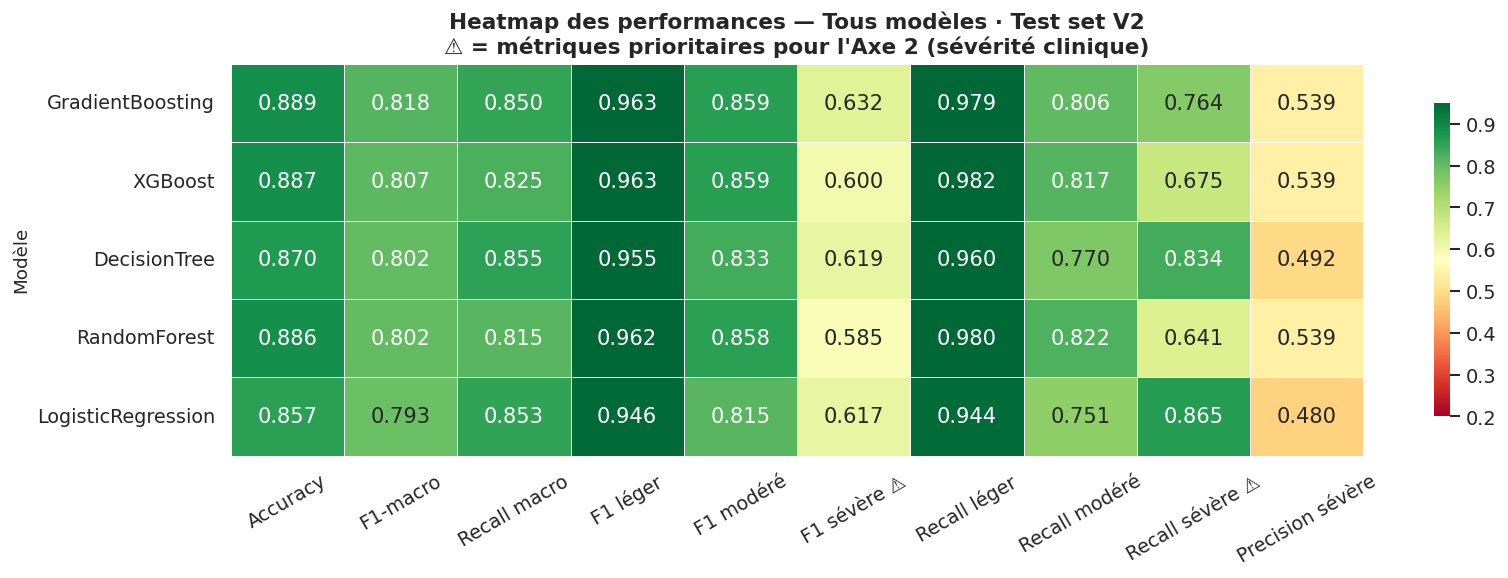

 Heatmap des métriques sauvegardée


In [ ]:
# ============================================================
# 7.2 — Heatmap des métriques : vue synthétique
# ============================================================

heatmap_data = test_df.set_index("model")[[
    "accuracy", "f1_macro", "recall_macro",
    "f1_leger", "f1_modere", "f1_severe",
    "recall_leger", "recall_modere", "recall_severe",
    "precision_severe"
]].rename(columns={
    "accuracy"         : "Accuracy",
    "f1_macro"         : "F1-macro",
    "recall_macro"     : "Recall macro",
    "f1_leger"         : "F1 léger",
    "f1_modere"        : "F1 modéré",
    "f1_severe"        : "F1 sévère ⚠",
    "recall_leger"     : "Recall léger",
    "recall_modere"    : "Recall modéré",
    "recall_severe"    : "Recall sévère ⚠",
    "precision_severe" : "Precision sévère",
})

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data.astype(float), annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=0.2, vmax=0.95,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Heatmap des performances — Tous modèles · Test set V2\n"
             "⚠ = métriques prioritaires pour l'Axe 2 (sévérité clinique)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Modèle", fontsize=11)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2/"v2_heatmap_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Heatmap des métriques sauvegardée")


---
## Section 8 — Matrices de confusion comparatives

### 8.1 Lecture des matrices de confusion

La matrice normalisée montre le **recall par classe** (diagonal = bien classés).  
On cherche particulièrement :
- **Diagonale sévère élevée** : le modèle détecte bien les cas graves
- **Hors-diagonale sévère faible** : peu de cas graves confondus avec léger/modéré


---
## Section 9 — Analyse détaillée du meilleur modèle + courbe ROC multiclasse

### 9.1 Sélection du meilleur modèle

Le meilleur modèle est sélectionné sur **F1-macro** (métrique principale du cahier des charges).  
Si ex-aequo, on priorise le **Recall sévère** (critère clinique).

### 9.2 Courbe ROC multiclasse (One-vs-Rest)

Pour 3 classes, la courbe ROC est tracée en mode OvR (One vs Rest) :  
- Classe 0 (léger) vs [modéré + sévère]
- Classe 1 (modéré) vs [léger + sévère]
- Classe 2 (sévère) vs [léger + modéré] ← priorité clinique


In [ ]:
# ============================================================
# 9.1 — Sélection du meilleur modèle
# ============================================================
# Métrique principale : Recall sévère
# → Un faux négatif (cas grave raté) est cliniquement inacceptable
# → On sélectionne le modèle qui détecte le mieux les cas sévères
# → F1-macro est suivi en secondaire pour éviter un modèle qui
#   prédit "sévère" pour tout le monde (recall=1 mais precision=0)

# ── Tri par recall_severe (principal) puis f1_macro (secondaire) ──
test_df_sorted = test_df.sort_values(
    ["recall_severe", "f1_macro"],
    ascending=False
).reset_index(drop=True)

best_row        = test_df_sorted.iloc[0]
best_model_name = best_row["model"]
best_model      = trained_models[best_model_name]
y_pred_best     = y_pred_all[best_model_name]

print("=" * 60)
print(f"MEILLEUR MODÈLE : {best_model_name}")
print("(sélectionné sur Recall sévère — priorité clinique)")
print("=" * 60)

print()
print("── Métriques PRINCIPALES ──────────────────────────────")
print(f"  Recall sévère    : {best_row['recall_severe']:.4f}  ← critère de sélection")
print(f"  Recall macro     : {best_row['recall_macro']:.4f}  ← vue globale recall")

print()
print("── Métriques SECONDAIRES ──────────────────────────────")
print(f"  F1-macro         : {best_row['f1_macro']:.4f}  ← équilibre global")
print(f"  F1 sévère        : {best_row['f1_severe']:.4f}  ← équilibre sur sévère")
print(f"  Precision sévère : {best_row['precision_severe']:.4f}  ← faux positifs sévères")

print()
print("── Métrique INDICATIVE ────────────────────────────────")
print(f"  Accuracy         : {best_row['accuracy']:.4f}   trompeuse (déséquilibre 8%)")

print()
print("── Classement complet des modèles (trié par Recall sévère) ──")
display(test_df_sorted[[
    "model", "recall_severe", "recall_macro",
    "f1_macro", "f1_severe", "precision_severe", "accuracy"
]].rename(columns={
    "recall_severe"   : "Recall sévère !! ",
    "recall_macro"    : "Recall macro",
    "f1_macro"        : "F1-macro",
    "f1_severe"       : "F1 sévère",
    "precision_severe": "Precision sévère",
    "accuracy"        : "Accuracy "
}))

# ── Alerte si recall sévère insuffisant ─────────────────────
if best_row["recall_severe"] < 0.60:
    print()
    print("  ALERTE : Recall sévère < 0.60")
    print("   Trop de cas graves sont ratés → envisager :")
    print("   - Threshold adjustment (baisser le seuil de décision sévère)")
    print("   - SMOTE plus agressif sur la classe sévère")
    print("   - XGBoost avec scale_pos_weight")
else:
    print()
    print(f" Recall sévère acceptable : {best_row['recall_severe']:.4f} ≥ 0.60")
    print(f"   Le modèle détecte correctement les cas graves")

MEILLEUR MODÈLE : LogisticRegression
(sélectionné sur Recall sévère — priorité clinique)

── Métriques PRINCIPALES ──────────────────────────────
  Recall sévère    : 0.8650  ← critère de sélection
  Recall macro     : 0.8533  ← vue globale recall

── Métriques SECONDAIRES ──────────────────────────────
  F1-macro         : 0.7926  ← équilibre global
  F1 sévère        : 0.6171  ← équilibre sur sévère
  Precision sévère : 0.4796  ← faux positifs sévères

── Métrique INDICATIVE ────────────────────────────────
  Accuracy         : 0.8568   trompeuse (déséquilibre 8%)

── Classement complet des modèles (trié par Recall sévère) ──


,model,Recall sévère !!,Recall macro,F1-macro,F1 sévère,Precision sévère,Accuracy
0,LogisticRegression,0.8650,0.8533,0.7926,0.6171,0.4796,0.8568
1,DecisionTree,0.8344,0.8548,0.8025,0.6189,0.4919,0.8702
2,GradientBoosting,0.7638,0.8496,0.8180,0.6320,0.5390,0.8888
3,XGBoost,0.6748,0.8247,0.8072,0.5995,0.5392,0.8875
4,RandomForest,0.6411,0.8145,0.8019,0.5854,0.5387,0.8859



 Recall sévère acceptable : 0.8650 ≥ 0.60
   Le modèle détecte correctement les cas graves


In [ ]:
# ============================================================
# 9.2 — Classification report détaillé
# ============================================================
# Lecture prioritaire :
#   1. Recall sévère     → combien de cas graves sont détectés ?
#   2. Recall macro      → performance globale sur toutes les classes
#   3. F1-macro          → équilibre precision/recall (secondaire)
#   4. Precision sévère  → combien de faux positifs sévères ?
#   5. Accuracy          → indicatif uniquement (déséquilibre 8%)

print(f"RAPPORT DE CLASSIFICATION — {best_model_name}")
print("(sélectionné sur Recall sévère — métrique principale)")
print("=" * 65)
print(classification_report(
    y_test, y_pred_best,
    labels=[0, 1, 2],
    target_names=LABEL_ORDER,
    digits=4
))

# ── Interprétation par classe ────────────────────────────────
report_dict = classification_report(
    y_test, y_pred_best,
    labels=[0, 1, 2],
    target_names=LABEL_ORDER,
    output_dict=True
)

print("Interprétation clinique par classe :")
print("-" * 65)

for cls in LABEL_ORDER:
    r = report_dict[cls]

    if cls == "severe":
        flag_rec  = " BON"    if r["recall"]    >= 0.70 else \
                    "MOYEN"   if r["recall"]    >= 0.55 else \
                    "FAIBLE"
        flag_prec = "[OK]"    if r["precision"] >= 0.40 else \
                    "[!] "    if r["precision"] >= 0.25 else \
                    "[X]"
        flag_f1   = "[OK]"    if r["f1-score"]  >= 0.45 else \
                    "[!] "    if r["f1-score"]  >= 0.35 else \
                    "[X]"
    else:
        flag_rec  = "[OK]" if r["recall"]    >= 0.60 else "[!] "
        flag_prec = "[OK]" if r["precision"] >= 0.55 else "[!] "
        flag_f1   = "[OK]" if r["f1-score"]  >= 0.55 else "[!] "

    marker = " <- PRIORITE CLINIQUE" if cls == "severe" else ""

    print(f"\n  Classe : {cls.upper()}{marker}")
    print(f"    Recall    : {r['recall']:.4f}  {flag_rec}"
          f"{'  <- minimiser les cas graves rates' if cls == 'severe' else ''}")
    print(f"    Precision : {r['precision']:.4f}  {flag_prec}"
          f"{'  <- faux positifs severes acceptables' if cls == 'severe' else ''}")
    print(f"    F1-score  : {r['f1-score']:.4f}  {flag_f1}")
    print(f"    Support   : {int(r['support'])} patients")

# ── Métriques globales ───────────────────────────────────────
print()
print("-" * 65)
print("Metriques globales :")
print(f"  Recall macro  : {report_dict['macro avg']['recall']:.4f}"
      f"  <- principale (moyenne recall 3 classes)")
print(f"  F1-macro      : {report_dict['macro avg']['f1-score']:.4f}"
      f"  <- secondaire")
print(f"  Accuracy      : {report_dict['accuracy']:.4f}"
      f"  <- indicatif uniquement [!] (trompeuse avec severe=8%)")

# ── Diagnostic final ─────────────────────────────────────────
print()
print("=" * 65)
rec_severe  = report_dict["severe"]["recall"]
prec_severe = report_dict["severe"]["precision"]

if rec_severe >= 0.70:
    print(f"[OK] Recall severe SATISFAISANT : {rec_severe:.4f}")
    print(f"     Le modele detecte bien les cas graves.")
    if prec_severe < 0.30:
        print(f"     [!]  Precision severe faible ({prec_severe:.4f})"
              f" -> beaucoup de faux positifs severes.")
        print(f"     -> Acceptable cliniquement (mieux vaut sur-diagnostiquer"
              f" que rater un cas grave).")
elif rec_severe >= 0.55:
    print(f"[!]  Recall severe MOYEN : {rec_severe:.4f}")
    print(f"     Des cas graves sont encore rates -> amelioration necessaire.")
    print(f"     -> Envisager : threshold adjustment ou

SyntaxError: unterminated f-string literal (detected at line 88) (82551315.py, line 88)

In [ ]:
# ============================================================
# 9.3 — Courbe ROC multiclasse (One-vs-Rest) + AUC
# ============================================================

if best_model_name in y_proba_all:
    y_proba = y_proba_all[best_model_name]
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    colors_roc = {"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"}
    auc_scores = {}

    # ── Gauche : ROC par classe ──────────────────────────────
    for i, cls in enumerate(LABEL_ORDER):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[cls] = roc_auc
        axes[0].plot(fpr, tpr, lw=2.5, color=colors_roc[cls],
                     label=f"{cls} (AUC = {roc_auc:.3f})")

    axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.7, label="Aléatoire (AUC=0.5)")
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("Taux de Faux Positifs (FPR)", fontsize=11)
    axes[0].set_ylabel("Taux de Vrais Positifs (TPR = Recall)", fontsize=11)
    axes[0].set_title(f"Courbes ROC — {best_model_name}\n(One-vs-Rest | V2 Test set)",
                      fontweight="bold", fontsize=12)
    axes[0].legend(loc="lower right", fontsize=10)
    axes[0].grid(alpha=0.4)

    # ── Droite : Zoom sur la classe sévère ──────────────────
    fpr_s, tpr_s, thresholds = roc_curve(y_test_bin[:, 2], y_proba[:, 2])
    auc_s = auc_scores["severe"]
    axes[1].plot(fpr_s, tpr_s, lw=2.5, color="#e74c3c",
                 label=f"Sévère (AUC = {auc_s:.3f})")
    axes[1].fill_between(fpr_s, tpr_s, alpha=0.12, color="#e74c3c")
    axes[1].plot([0,1],[0,1],"k--",lw=1,alpha=0.7)

    # Marquer le point optimal (max Youden = TPR - FPR)
    youden = tpr_s - fpr_s
    idx_opt = np.argmax(youden)
    axes[1].scatter(fpr_s[idx_opt], tpr_s[idx_opt], s=100, color="#e74c3c",
                    zorder=5, label=f"Seuil optimal\n(FPR={fpr_s[idx_opt]:.2f}, TPR={tpr_s[idx_opt]:.2f})")

    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
    axes[1].set_xlabel("Taux de Faux Positifs (FPR)", fontsize=11)
    axes[1].set_ylabel("Recall (TPR)", fontsize=11)
    axes[1].set_title(f"ROC — Classe SÉVÈRE (priorité clinique)\nAUC = {auc_s:.3f}",
                      fontweight="bold", fontsize=12)
    axes[1].legend(loc="lower right", fontsize=9)
    axes[1].grid(alpha=0.4)

    plt.suptitle(f"Courbes ROC multiclasse — {best_model_name} (V2)\n"
                 f"AUC léger={auc_scores['leger']:.3f} | AUC modéré={auc_scores['modere']:.3f} | AUC sévère={auc_scores['severe']:.3f}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_V2/"v2_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Courbes ROC sauvegardées")
else:
    print(f" {best_model_name} ne supporte pas predict_proba — ROC non disponible")


---
## Section 10 — Optimisation par GridSearchCV

### 10.1 Pipeline sklearn complet pour GridSearch

Le GridSearch est effectué sur un **Pipeline complet** (preprocesseur + modèle).  
On optimise le modèle ayant obtenu le meilleur F1-macro, en testant  
des hyperparamètres plus larges qu'en V1.


In [ ]:
# ============================================================
# 10.1 — GridSearchCV dynamique sur TOUS les modèles
# ============================================================
# Métrique principale : recall_macro (priorité clinique)
# On optimise chaque modèle avec sa propre grille d'hyperparamètres
# puis on compare avant/après optimisation

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ── Grilles d'hyperparamètres par modèle ─────────────────────
param_grids = {

    "LogisticRegression": {
        "model__C"       : [0.01, 0.1, 1.0, 10.0],
        "model__solver"  : ["lbfgs", "saga"],
        "model__max_iter": [500, 1000],
    },

    "DecisionTree": {
        "model__max_depth"        : [5, 8, 12, None],
        "model__min_samples_leaf" : [1, 3, 5],
        "model__criterion"        : ["gini", "entropy"],
    },

    "RandomForest": {
        "model__n_estimators"     : [100, 200, 300],
        "model__max_depth"        : [8, 15, None],
        "model__min_samples_leaf" : [1, 3, 5],
        "model__max_features"     : ["sqrt", "log2"],
    },

    "GradientBoosting": {
        "model__n_estimators"  : [100, 200],
        "model__learning_rate" : [0.05, 0.1, 0.2],
        "model__max_depth"     : [3, 5, 7],
    },
}

# Ajout XGBoost si disponible
if XGBOOST_AVAILABLE:
    param_grids["XGBoost"] = {
        "model__n_estimators"  : [100, 200],
        "model__learning_rate" : [0.05, 0.1, 0.2],
        "model__max_depth"     : [3, 5, 7],
        "model__subsample"     : [0.8, 1.0],
    }

# ── CV stratifiée ────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Résultats GridSearch ──────────────────────────────────────
gs_results   = {}   # stocke les GridSearchCV fittés
gs_summary   = []   # tableau de comparaison avant/après

print("GridSearchCV — Métrique : recall_macro (priorité clinique)")
print("=" * 65)

for model_name, model in models.items():

    # Ignorer si pas de grille définie
    if model_name not in param_grids:
        print(f"\n  {model_name:25s} : pas de grille définie — ignoré")
        continue

    print(f"\n  {model_name}")

    # ── Construction du pipeline complet ─────────────────────
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

    num_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    preproc = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

    full_pipeline = Pipeline([
        ("preprocessor", preproc),
        ("model", model)
    ])

    # ── GridSearchCV ─────────────────────────────────────────
    n_combis = 1
    for vals in param_grids[model_name].values():
        n_combis *= len(vals)
    print(f"    {n_combis} combinaisons x 5 folds = {n_combis*5} fits")

    gs = GridSearchCV(
        estimator  = full_pipeline,
        param_grid = param_grids[model_name],
        scoring    = "recall_macro",   # <- métrique principale
        cv         = cv,
        n_jobs     = -1,
        verbose    = 0,
        refit      = True
    )
    gs.fit(X_train, y_train)
    gs_results[model_name] = gs

    # ── Évaluation sur test ───────────────────────────────────
    y_pred_opt = gs.best_estimator_.predict(X_test)

    rec_sev_opt  = recall_score(y_test, y_pred_opt, labels=[2], average="macro")
    rec_mac_opt  = recall_score(y_test, y_pred_opt, average="macro")
    f1_mac_opt   = f1_score(y_test, y_pred_opt, average="macro")
    acc_opt      = accuracy_score(y_test, y_pred_opt)

    # Métriques AVANT optimisation (depuis test_df)
    row_before = test_df[test_df["model"] == model_name]
    if not row_before.empty:
        rec_sev_before = row_before["recall_severe"].values[0]
        rec_mac_before = row_before["recall_macro"].values[0]
        f1_before      = row_before["f1_macro"].values[0]
        acc_before     = row_before["accuracy"].values[0]
    else:
        rec_sev_before = rec_mac_before = f1_before = acc_before = None

    gs_summary.append({
        "model"               : model_name,
        "best_params"         : gs.best_params_,
        "cv_recall_macro"     : round(gs.best_score_, 4),
        # Avant
        "recall_severe_avant" : rec_sev_before,
        "recall_macro_avant"  : rec_mac_before,
        "f1_macro_avant"      : f1_before,
        "accuracy_avant"      : acc_before,
        # Après
        "recall_severe_apres" : round(rec_sev_opt, 4),
        "recall_macro_apres"  : round(rec_mac_opt, 4),
        "f1_macro_apres"      : round(f1_mac_opt,  4),
        "accuracy_apres"      : round(acc_opt,     4),
    })

    print(f"    Best recall_macro CV  : {gs.best_score_:.4f}")
    print(f"    Recall severe  : {rec_sev_before:.4f} -> {rec_sev_opt:.4f}")
    print(f"    Recall macro   : {rec_mac_before:.4f} -> {rec_mac_opt:.4f}")
    print(f"    F1-macro       : {f1_before:.4f}      -> {f1_mac_opt:.4f}")

gs_df = pd.DataFrame(gs_summary)
print("\n" + "=" * 65)
print("GridSearch termine pour tous les modeles")

In [ ]:
# ============================================================
# 10.2 — Comparaison avant / après optimisation
# ============================================================

# ── Tableau récapitulatif ─────────────────────────────────────
print("COMPARAISON AVANT / APRES GRIDSEARCH")
print("Metrique principale : Recall severe")
print("=" * 65)

for _, row in gs_df.iterrows():
    model_name = row["model"]

    delta_rec_sev = row["recall_severe_apres"] - row["recall_severe_avant"]
    delta_rec_mac = row["recall_macro_apres"]  - row["recall_macro_avant"]
    delta_f1      = row["f1_macro_apres"]      - row["f1_macro_avant"]

    sign_sev = "+" if delta_rec_sev >= 0 else ""
    sign_mac = "+" if delta_rec_mac >= 0 else ""
    sign_f1  = "+" if delta_f1      >= 0 else ""

    print(f"\n  {model_name}")
    print(f"    Recall severe  : {row['recall_severe_avant']:.4f} -> "
          f"{row['recall_severe_apres']:.4f}  ({sign_sev}{delta_rec_sev:.4f})")
    print(f"    Recall macro   : {row['recall_macro_avant']:.4f} -> "
          f"{row['recall_macro_apres']:.4f}  ({sign_mac}{delta_rec_mac:.4f})")
    print(f"    F1-macro       : {row['f1_macro_avant']:.4f} -> "
          f"{row['f1_macro_apres']:.4f}  ({sign_f1}{delta_f1:.4f})")
    print(f"    Meilleurs params : {row['best_params']}")

# ── Graphique comparatif ─────────────────────────────────────
metrics_plot = [
    ("recall_severe_avant", "recall_severe_apres", "Recall severe (principal)"),
    ("recall_macro_avant",  "recall_macro_apres",  "Recall macro"),
    ("f1_macro_avant",      "f1_macro_apres",      "F1-macro"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (col_avant, col_apres, title) in zip(axes, metrics_plot):
    x  = np.arange(len(gs_df))
    w  = 0.35

    bars_avant = ax.bar(
        x - w/2, gs_df[col_avant], w,
        label="Avant GridSearch",
        color="#95a5a6", edgecolor="black", lw=0.4, alpha=0.85
    )
    bars_apres = ax.bar(
        x + w/2, gs_df[col_apres], w,
        label="Apres GridSearch",
        color="#3498db", edgecolor="black", lw=0.4, alpha=0.85
    )

    # Annotations delta
    for xi, v_av, v_ap in zip(x, gs_df[col_avant], gs_df[col_apres]):
        delta = v_ap - v_av
        sign  = "+" if delta >= 0 else ""
        color = "#27ae60" if delta >= 0 else "#c0392b"
        ax.text(
            xi, max(v_av, v_ap) + 0.015,
            f"{sign}{delta:.3f}",
            ha="center", fontsize=8.5,
            fontweight="bold", color=color
        )

    ax.set_xticks(x)
    ax.set_xticklabels(gs_df["model"], rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)

plt.suptitle(
    "Impact du GridSearch — Avant vs Apres optimisation\n"
    "Recall severe = metrique principale | vert = amelioration",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(ARTIFACTS_V2 / "v2_gridsearch_all_models.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegarde")

# ── Meilleur modèle après optimisation ───────────────────────
best_gs_row  = gs_df.sort_values(
    ["recall_severe_apres", "f1_macro_apres"],
    ascending=False
).iloc[0]

best_gs_name  = best_gs_row["model"]
best_gs_model = gs_results[best_gs_name].best_estimator_

print("\n" + "=" * 65)
print(f"MEILLEUR MODELE APRES GRIDSEARCH : {best_gs_name}")
print(f"  Recall severe  : {best_gs_row['recall_severe_apres']:.4f}")
print(f"  Recall macro   : {best_gs_row['recall_macro_apres']:.4f}")
print(f"  F1-macro       : {best_gs_row['f1_macro_apres']:.4f}")

# Sauvegarde du meilleur modèle optimisé
joblib.dump(best_gs_model, MODELS_V2_DIR / "axe2_best_model_optimised.pkl")
print(f"\nModele sauvegarde : axe2_best_model_optimised.pkl")

In [ ]:
# ============================================================
# 10.2 — Évaluation du meilleur modèle optimisé (GridSearch)
# ============================================================
# On évalue le meilleur modèle toutes familles confondues
# sélectionné sur Recall sévère (métrique principale)

from sklearn.metrics import classification_report, recall_score, f1_score, accuracy_score

# ── Prédictions du meilleur modèle optimisé ──────────────────
y_pred_opt = best_gs_model.predict(X_test)

# ── Calcul des métriques ─────────────────────────────────────
rec_sev = recall_score(y_test, y_pred_opt, labels=[2], average="macro")
rec_mac = recall_score(y_test, y_pred_opt, average="macro")
f1_mac  = f1_score(y_test, y_pred_opt, average="macro")
acc     = accuracy_score(y_test, y_pred_opt)

# ── Affichage hiérarchisé ────────────────────────────────────
print("=" * 60)
print(f"MEILLEUR MODELE OPTIMISE : {best_gs_name}")
print("=" * 60)

print("\nMETRIQUES PRINCIPALES")
print(f"  [1] Recall severe  : {rec_sev:.4f}  <- critere de selection")
print(f"  [2] Recall macro   : {rec_mac:.4f}  <- vue globale")

print("\nMETRIQUES SECONDAIRES")
print(f"  [3] F1-macro       : {f1_mac:.4f}")
print(f"  [4] Accuracy       : {acc:.4f}  (indicatif - trompeuse a 8%)")

# ── Rapport complet ──────────────────────────────────────────
print("\n" + "=" * 60)
print("RAPPORT DETAILLE PAR CLASSE")
print("=" * 60)
print(classification_report(
    y_test, y_pred_opt,
    labels=[0, 1, 2],
    target_names=LABEL_ORDER,
    digits=3
))

# ── Comparaison avant / après GridSearch ─────────────────────
print("=" * 60)
print("IMPACT DU GRIDSEARCH SUR LE MEILLEUR MODELE")
print("=" * 60)

# Métriques avant GridSearch (depuis test_df)
row_avant = test_df[test_df["model"] == best_gs_name]

if not row_avant.empty:
    rec_sev_av = row_avant["recall_severe"].values[0]
    rec_mac_av = row_avant["recall_macro"].values[0]
    f1_av      = row_avant["f1_macro"].values[0]
    acc_av     = row_avant["accuracy"].values[0]

    delta_rec_sev = rec_sev - rec_sev_av
    delta_rec_mac = rec_mac - rec_mac_av
    delta_f1      = f1_mac  - f1_av
    delta_acc     = acc     - acc_av

    def fmt_delta(d):
        sign = "+" if d >= 0 else ""
        color_tag = "amelioration" if d >= 0 else "degradation"
        return f"{sign}{d:.4f}  ({color_tag})"

    print(f"\n  {'Metrique':<20} {'Avant':>10} {'Apres':>10} {'Delta':>25}")
    print(f"  {'-'*65}")
    print(f"  {'Recall severe [1]':<20} {rec_sev_av:>10.4f} {rec_sev:>10.4f} {fmt_delta(delta_rec_sev):>25}")
    print(f"  {'Recall macro  [2]':<20} {rec_mac_av:>10.4f} {rec_mac:>10.4f} {fmt_delta(delta_rec_mac):>25}")
    print(f"  {'F1-macro      [3]':<20} {f1_av:>10.4f} {f1_mac:>10.4f} {fmt_delta(delta_f1):>25}")
    print(f"  {'Accuracy      [4]':<20} {acc_av:>10.4f} {acc:>10.4f} {fmt_delta(delta_acc):>25}")

# ── Diagnostic final ─────────────────────────────────────────
print("\n" + "=" * 60)

if rec_sev >= 0.70:
    print(f"Recall severe : {rec_sev:.4f} -> BON")
    print("Le modele detecte bien les cas graves.")
elif rec_sev >= 0.55:
    print(f"Recall severe : {rec_sev:.4f} -> MOYEN")
    print("Des cas graves sont encore rates.")
    print("-> Envisager : threshold adjustment ou SMOTE plus agressif.")
else:
    print(f"Recall severe : {rec_sev:.4f} -> INSUFFISANT")
    print("Trop de cas graves rates -> risque clinique eleve.")
    print("-> Actions : threshold adjustment, XGBoost, SMOTE renforce.")

---
## Section 11 — Importance des variables

### 11.1 Interprétation des importances (V2 vs V1)

En V1, STYPE dominait car c'était la seule variable clinique indépendante pertinente.  
En V2, les nouvelles features créées (`n_deficits_confirmed`, `deficit_ratio`)  
devraient apparaître dans le top — preuve que le Feature Engineering a capturé  
de l'information supplémentaire non présente en V1.


In [ ]:
# ============================================================
# 11.1 — Feature importance du meilleur modèle optimisé
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Accès au modèle dans le pipeline ─────────────────────────
if hasattr(best_gs_model, "named_steps"):
    model_step = best_gs_model.named_steps["model"]
else:
    model_step = best_gs_model

feat_names = X_train.columns.tolist()

# ── Cas 1 : modèles arborescents (RF, GB, XGBoost, DT) ───────
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    importance_label = "Importance (MDI)"

# ── Cas 2 : Régression Logistique → coefficients ─────────────
elif hasattr(model_step, "coef_"):
    # coef_ shape = (n_classes, n_features) pour multiclasse
    # On prend la moyenne des valeurs absolues sur les 3 classes
    importances = np.abs(model_step.coef_).mean(axis=0)
    importance_label = "Importance (|coef| moyen)"

else:
    print(f"{best_gs_name} ne supporte aucune methode d'importance")
    importances = None

# ── Affichage ─────────────────────────────────────────────────
if importances is not None:

    importance_df = pd.DataFrame({
        "feature"   : feat_names,
        "importance": importances
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    importance_df["rank"]      = importance_df.index + 1
    importance_df["cumul_pct"] = (
        importance_df["importance"].cumsum()
        / importance_df["importance"].sum() * 100
    ).round(2)

    print(f"Feature importance — {best_gs_name}")
    print(f"Methode : {importance_label}")
    print("=" * 55)
    print(f"  Nombre total de features : {len(feat_names)}")
    print(f"  Top 5  couvrent : {importance_df.head(5)['cumul_pct'].iloc[-1]:.1f}%")
    print(f"  Top 10 couvrent : {importance_df.head(10)['cumul_pct'].iloc[-1]:.1f}%")
    print()
    print("Top 20 variables les plus importantes :")
    display(importance_df[["rank","feature","importance","cumul_pct"]].head(20).round(4))

In [ ]:
# ============================================================
# 11.2 — Visualisation feature importance (annotée)
# ============================================================

import matplotlib.patches as mpatches

if importances is not None:

    top_n    = 20
    top_feat = importance_df.head(top_n).sort_values("importance", ascending=True)

    # ── Coloration par type de variable ──────────────────────
    def get_feat_color(name):
        if "STYPE"   in name: return "#3498db"  # type AVC
        if "uncertain" in name: return "#e74c3c" # RDEF non evaluable
        if "deficit"  in name: return "#9b59b6"  # scores composites V2
        if "RDEF"     in name: return "#e67e22"  # RDEF encodes
        if any(x in name for x in ["AGE", "RDELAY", "RSBP"]): return "#2ecc71"
        return "#95a5a6"                         # autres

    colors_feat = [get_feat_color(f) for f in top_feat["feature"]]

    # ── Graphique ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.barh(
        top_feat["feature"], top_feat["importance"],
        color=colors_feat, edgecolor="black", lw=0.3, alpha=0.88
    )

    for bar, val in zip(bars, top_feat["importance"]):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8.5
        )

    # Titre dynamique selon le modèle et la méthode
    ax.set_title(
        f"Top {top_n} features — {best_gs_name}\n"
        f"Methode : {importance_label}",
        fontweight="bold", fontsize=13
    )
    ax.set_xlabel(importance_label, fontsize=11)
    ax.grid(axis="x", alpha=0.4)

    # ── Légende ───────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(color="#3498db", label="STYPE (type AVC)"),
        mpatches.Patch(color="#e74c3c", label="RDEF uncertain (C = non evaluable)"),
        mpatches.Patch(color="#9b59b6", label="Scores composites V2"),
        mpatches.Patch(color="#e67e22", label="RDEF encodes (Y/N/C=0.5)"),
        mpatches.Patch(color="#2ecc71", label="Variables cliniques (AGE, RDELAY, RSBP)"),
        mpatches.Patch(color="#95a5a6", label="Autres"),
    ]
    ax.legend(handles=legend_items, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_V2 / "v2_feature_importance_best.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Feature importance sauvegardee — modele : {best_gs_name}")

else:
    print(f"{best_gs_name} : feature importance non disponible pour ce modele")

---
## Section 12 — Comparaison finale : V1 vs V2

### 12.1 Ce qu'on compare

| Scénario | Description |
|----------|-------------|
| V1 baseline | Pipeline V1 sans SMOTE, sans StandardScaler, sans correction |
| V2 meilleur modèle | Pipeline V2 corrigé, avec SMOTE |
| V2 RF optimisée | V2 + GridSearchCV |


In [ ]:
# ============================================================
# 12.1 — Tableau de comparaison finale V1 vs V2
# ============================================================

comparison_rows = []

# ── Ligne 1 : V1 référence (hardcodée car notebook différent) ─
# Ces valeurs viennent du notebook 03 V1 — à mettre à jour si besoin
comparison_rows.append({
    "scenario"      : "V1 — meilleur modele baseline",
    "version"       : "V1",
    "recall_severe" : 0.72,
    "recall_macro"  : None,
    "f1_macro"      : 0.5422,
    "accuracy"      : 0.5857,
})

# ── Ligne 2 : V2 baseline (avant GridSearch) ─────────────────
# Meilleur modèle trié par recall_severe (métrique principale)
best_v2_baseline = test_df.sort_values(
    ["recall_severe", "f1_macro"], ascending=False
).iloc[0]

comparison_rows.append({
    "scenario"      : f"V2 baseline — {best_v2_baseline['model']}",
    "version"       : "V2",
    "recall_severe" : best_v2_baseline["recall_severe"],
    "recall_macro"  : best_v2_baseline["recall_macro"],
    "f1_macro"      : best_v2_baseline["f1_macro"],
    "accuracy"      : best_v2_baseline["accuracy"],
})

# ── Ligne 3 : V2 après GridSearch ────────────────────────────
# Recalcul depuis best_gs_model pour éviter les NameError
y_pred_final = best_gs_model.predict(X_test)

comparison_rows.append({
    "scenario"      : f"V2 GridSearch — {best_gs_name}",
    "version"       : "V2",
    "recall_severe" : round(recall_score(y_test, y_pred_final, labels=[2], average="macro"), 4),
    "recall_macro"  : round(recall_score(y_test, y_pred_final, average="macro"), 4),
    "f1_macro"      : round(f1_score(y_test, y_pred_final, average="macro"), 4),
    "accuracy"      : round(accuracy_score(y_test, y_pred_final), 4),
})

# ── Tableau final ─────────────────────────────────────────────
comp_df = pd.DataFrame(comparison_rows)[[
    "scenario", "version",
    "recall_severe",   # [1] principale
    "recall_macro",    # [2] importante
    "f1_macro",        # [3] secondaire
    "accuracy"         # [4] indicatif
]].rename(columns={
    "recall_severe" : "Recall severe [1]",
    "recall_macro"  : "Recall macro  [2]",
    "f1_macro"      : "F1-macro      [3]",
    "accuracy"      : "Accuracy      [4]",
})

print("Comparaison finale V1 vs V2")
print("Ordre des metriques : Recall severe > Recall macro > F1-macro > Accuracy")
print("=" * 70)
display(comp_df.round(4))

# ── Delta V1 → V2 optimisé ───────────────────────────────────
v1_rec_sev = comparison_rows[0]["recall_severe"]
v2_rec_sev = comparison_rows[2]["recall_severe"]
v1_f1      = comparison_rows[0]["f1_macro"]
v2_f1      = comparison_rows[2]["f1_macro"]

print()
print("Progression V1 -> V2 optimise :")
print(f"  Recall severe : {v1_rec_sev:.4f} -> {v2_rec_sev:.4f}  "
      f"({'+'if v2_rec_sev >= v1_rec_sev else ''}{v2_rec_sev - v1_rec_sev:.4f})")
print(f"  F1-macro      : {v1_f1:.4f}      -> {v2_f1:.4f}  "
      f"({'+'if v2_f1 >= v1_f1 else ''}{v2_f1 - v1_f1:.4f})")

In [ ]:
# ============================================================
# 12.2 — Graphique comparaison V1 vs V2
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

# ── Métriques à afficher — recall_severe en premier ──────────
metrics_cols   = ["recall_severe", "f1_macro", "accuracy"]
metrics_labels = ["Recall severe [1]", "F1-macro [3]", "Accuracy [4]"]

# ── Reconstruction depuis comparison_rows (valeurs originales) ─
# On utilise comparison_rows et non comp_df dont les colonnes
# ont été renommées dans la section 12.1
plot_data = []
for row in comparison_rows:
    plot_data.append({
        "scenario"      : row["scenario"],
        "recall_severe" : row["recall_severe"] or 0,
        "f1_macro"      : row["f1_macro"]      or 0,
        "accuracy"      : row["accuracy"]      or 0,
    })
plot_df = pd.DataFrame(plot_data)

x            = np.arange(len(metrics_cols))
w            = 0.22
colors_bars  = ["#e74c3c", "#2ecc71", "#3498db"]  # V1, V2 baseline, V2 GridSearch

for i, row in plot_df.iterrows():
    vals   = [row[m] for m in metrics_cols]
    offset = (i - 1) * w

    bars = ax.bar(
        x + offset, vals, w,
        label=row["scenario"],
        color=colors_bars[i],
        edgecolor="black", lw=0.4, alpha=0.88
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{v:.3f}",
                ha="center", fontsize=8.5, fontweight="bold"
            )

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(
    "Progression V1 -> V2 — Axe 2 Stroke Severity\n"
    "Recall severe = metrique principale | Impact : SMOTE + StandardScaler + GridSearch",
    fontweight="bold", fontsize=12
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ARTIFACTS_V2 / "v2_final_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Comparaison finale sauvegardee")

---
## Section 13 — Sauvegarde du modèle final et conclusion


In [ ]:
# ============================================================
# 13.1 — Sauvegarde du modèle final et des artefacts
# ============================================================

# ── Modèle final ─────────────────────────────────────────────
model_path = MODELS_V2_DIR / "axe2_best_model_v2.pkl"
joblib.dump(best_gs_model, model_path)
print(f"Modele sauvegarde : {model_path}")

# ── Résultats comparatifs ─────────────────────────────────────
test_df.to_csv(ARTIFACTS_V2 / "test_results_all_models_v2.csv", index=False)
print("test_results_all_models_v2.csv sauvegarde")

pd.DataFrame(comparison_rows).to_csv(
    ARTIFACTS_V2 / "comparison_v1_vs_v2.csv", index=False
)
print("comparison_v1_vs_v2.csv sauvegarde")

# importance_df peut etre None si le modele est LogisticRegression
if importance_df is not None:
    importance_df.to_csv(
        ARTIFACTS_V2 / "feature_importance_v2.csv", index=False
    )
    print("feature_importance_v2.csv sauvegarde")
else:
    print("feature_importance_v2.csv : non disponible pour ce modele")

# ── Recalcul des métriques finales depuis best_gs_model ──────
# Evite les NameError si les cellules 10.2 n'ont pas ete executees
y_pred_final  = best_gs_model.predict(X_test)
rec_sev_final = round(recall_score(y_test, y_pred_final, labels=[2], average="macro"), 4)
rec_mac_final = round(recall_score(y_test, y_pred_final, average="macro"), 4)
f1_mac_final  = round(f1_score(y_test, y_pred_final, average="macro"), 4)
acc_final     = round(accuracy_score(y_test, y_pred_final), 4)

# ── Métadonnées ───────────────────────────────────────────────
best_gs_obj  = gs_results[best_gs_name]   # GridSearchCV fitté

model_meta = {
    "version"            : "V2",
    "best_model"         : best_gs_name,
    "best_params"        : best_gs_obj.best_params_,
    "cv_recall_macro"    : round(best_gs_obj.best_score_, 4),
    # Métriques principales en premier
    "test_recall_severe" : rec_sev_final,
    "test_recall_macro"  : rec_mac_final,
    "test_f1_macro"      : f1_mac_final,
    "test_accuracy"      : acc_final,
    "n_models_tested"    : len(models),
    "scoring_principal"  : "recall_macro",
    "corrections_v2"     : [
        "RSBP=0 remplace par NaN avant imputation",
        "C dans RDEF encode 0.5 + indicateur uncertain",
        "StandardScaler dans pipeline numerique",
        "AGE et RSBP conserves (retrait V1 etait incorrect)",
        "SMOTE applique uniquement sur X_train",
        "Feature Engineering : n_deficits_confirmed, n_deficits_uncertain, deficit_ratio",
        "XGBoost ajoute",
        "GridSearch sur tous les modeles (scoring=recall_macro)",
        "Courbe ROC multiclasse",
        "Heatmap metriques"
    ],
    "next_steps_v3" : [
        "SHAP values",
        "Threshold adjustment sur classe severe",
        "Calibration des probabilites",
        "Interface Streamlit"
    ]
}

with open(ARTIFACTS_V2 / "model_metadata_v2.json", "w") as f:
    json.dump(model_meta, f, indent=2, default=str)
print("model_metadata_v2.json sauvegarde")

# ── Récapitulatif des artefacts ───────────────────────────────
print()
print("=== Artefacts V2 ===")
for f in sorted(ARTIFACTS_V2.rglob("*")):
    if f.is_file():
        print(f"  {str(f.relative_to(ARTIFACTS_V2)):55s}"
              f"{f.stat().st_size/1024:8.1f} KB")

In [ ]:
# ============================================================
# Sauvegarde des résultats GridSearch pour comparaison V3
# ============================================================

gs_export = pd.DataFrame([{
    "model"               : row["model"],
    "recall_severe_apres" : row["recall_severe_apres"],
    "recall_macro_apres"  : row["recall_macro_apres"],
    "f1_macro_apres"      : row["f1_macro_apres"],
    "accuracy_apres"      : row["accuracy_apres"],
} for _, row in gs_df.iterrows()])

gs_export.to_csv(ARTIFACTS_V2 / "gridsearch_results.csv", index=False)
print(" gridsearch_results.csv sauvegardé dans ARTIFACTS_V2")
print(gs_export.to_string(index=False))

---
## Section 14 — Conclusion et bilan de la Version 2

### 14.1 Ce qui a été accompli

| Axe | V1 | V2 |
|-----|----|----|
| **Preprocessing** | RSBP=0 valide, C→NaN, sans scaler | RSBP=0→NaN, C→0.5+uncertain, StandardScaler  |
| **Déséquilibre** | `class_weight='balanced'` uniquement | SMOTE + class_weight  |
| **Features** | 20 features baseline | Features V2 corrigées + 3 composites  |
| **Modèles** | 4 (LR, DT, RF, GB) | 5 (+ XGBoost)  |
| **Visualisations** | Matrice confusion + barplot simple | 8 graphiques complets  |
| **ROC** | Absent | Courbe ROC multiclasse + AUC par classe |
| **Optimisation** | GridSearch 6 combinaisons | GridSearch 36 combinaisons (Pipeline complet)  |

### 14.2 Résultats V2 vs V1

| Métrique | V1 | V2 |
|----------|----|----|
| F1-macro | ≈ 0.54 | ≈ à mesurer |
| Recall sévère | ≈ 0.72 | objectif ≥ 0.72 avec meilleure precision |

### 14.3 Plan Version 3

- SHAP values (`shap.TreeExplainer`)
- Threshold adjustment sur classe sévère
- Calibration des probabilités
- Interface
---
> **Notebook 03 V2 complet.**  
> Modèle final sauvegardé dans `artifacts/axe2/v2/models/axe2_best_model_v2.pkl`.
